# 04 — Model Selection, Tuning and Calibration

**Input:** `train.parquet`, `feature_decision.json`

**Output:** `model_selection.json`, `final_pipeline.joblib`

Notebook 03 established a logistic baseline capturing 23.3% of the available headroom, and Box-Tidwell showed that two of three numeric predictors violate linearity of the logit. That is a measured reason to expect tree ensembles to help, rather than a hunch.

**Three commitments carried in from the validation design.**

The decision threshold is a hyperparameter. Selecting a cutoff on the same data you report from is the leakage this project polices everywhere else, and it slips past constantly because a threshold does not feel like a fitted parameter. Part 5 selects it inside the inner loop only.

Comparing four models pairwise means six tests, and at the conventional cutoff roughly one spurious result is expected per twenty comparisons. Part 3 runs Friedman across all models first and only proceeds to pairwise tests if it rejects.

Every look at the validation folds spends some of their credibility. Part 0 counts those looks and records the number, because a model chosen after three hundred comparisons deserves more scepticism than one chosen after five — and the count is the only evidence of which happened.

**What this notebook does not do:** it never touches `test.parquet`. Final evaluation, interpretation, and per-prediction uncertainty belong in notebook 05.

---

## Setup

In [1]:
# Restart the kernel after this cell before running the rest.
%pip install -q --force-reinstall --no-deps git+https://github.com/rbennum/telco-churn.git
%pip install -q pyarrow joblib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from telco_churn.config import RANDOM_SEED, TARGET, OUT_DIR, ensure_out_dir, find_artifact
from telco_churn.business import (
    COST_ASSUMPTIONS,
    cost_per_customer,
    optimal_threshold,
    policy_from_proba,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
sklearn.set_config(transform_output="pandas")

ensure_out_dir()
print(f"sklearn {sklearn.__version__} | seed {RANDOM_SEED}")

sklearn 1.6.1 | seed 29


In [3]:
train = pd.read_parquet(find_artifact("train.parquet"))
manifest = json.loads(find_artifact("ingest_manifest.json").read_text())
decision03 = json.loads(find_artifact("feature_decision.json").read_text())

assert len(train) == manifest["train_rows"], "Stale train.parquet"
assert manifest["random_seed"] == RANDOM_SEED, "Seed mismatch with notebook 01"

X = train.drop(columns=[TARGET])
y = train[TARGET]

BASELINE_COST = decision03["metrics"]["cost_per_customer"]
ORACLE = decision03["benchmarks"]["oracle"]
BEST_NAIVE = decision03["benchmarks"]["best_naive"]
HEADROOM = decision03["benchmarks"]["headroom"]
CHOSEN_FEATURES = decision03["chosen_feature_set"]

print(f"feature set from notebook 03 : {CHOSEN_FEATURES}")
print(f"baseline cost to beat        : USD {BASELINE_COST:.4f}")
print(f"oracle ceiling               : USD {ORACLE:.4f}")
print(f"best naive policy            : USD {BEST_NAIVE:.4f}")
print(f"headroom                     : USD {HEADROOM:.4f}")
print(f"baseline captured            : {(BEST_NAIVE - BASELINE_COST) / HEADROOM:.1%}")

feature set from notebook 03 : baseline
baseline cost to beat        : USD 97.3271
oracle ceiling               : USD 84.4488
best naive policy            : USD 101.2287
headroom                     : USD 16.7800
baseline captured            : 23.3%


---

## 0. Validation Query Budget

Across many experiments you begin selecting the configuration that best fits validation noise rather than the one that generalises. Every individual experiment can follow the rules perfectly and the selection still degrades — one search with many degrees of freedom is not many honest tests.

There is no way to undo that. What is possible is to count the looks and report the number, so a reader can discount accordingly.

In [4]:
class QueryBudget:
    """Counts evaluations against the validation folds."""

    def __init__(self):
        self.log = []

    def record(self, label, n_configs=1):
        self.log.append({"label": label, "configs": n_configs})
        return n_configs

    @property
    def total(self):
        return sum(e["configs"] for e in self.log)

    def report(self):
        df = pd.DataFrame(self.log)
        print(df.to_string(index=False))
        print(f"\nTotal validation queries: {self.total}")
        if self.total > 200:
            print("High. Expect the gap between validation and test to widen.")
        elif self.total > 50:
            print("Moderate. Regression to the mean on the test set is likely.")
        else:
            print("Low. The reported estimate should hold up reasonably well.")
        return df


budget = QueryBudget()
print("Query budget initialised.")

Query budget initialised.


---

## 1. Pipeline Construction

The same builders as notebook 03, so any difference in score comes from the model rather than from a preprocessing change. Tree ensembles do not need scaling, but leaving it in costs nothing and keeps one code path — a second builder is a second thing that can silently diverge.

In [5]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


def build_preprocessor():
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric, make_column_selector(dtype_include=np.number)),
        ("cat", categorical, make_column_selector(dtype_include=object)),
    ], verbose_feature_names_out=False)


def build_pipeline(model):
    return Pipeline([("prep", build_preprocessor()), ("model", model)])


CANDIDATES = {
    "logistic": LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    "random_forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_SEED),
}

print(f"{len(CANDIDATES)} candidate models")
for k in CANDIDATES:
    print(f"  - {k}")

4 candidate models
  - logistic
  - random_forest
  - extra_trees
  - hist_gradient_boosting


In [6]:
def cost_scorer(estimator, X_fold, y_fold):
    """Negative expected cost at the per-customer derived threshold."""
    proba = estimator.predict_proba(X_fold)[:, 1]
    action = policy_from_proba(proba, X_fold["MonthlyCharges"], X_fold["Contract"])
    return -cost_per_customer(y_fold, action, X_fold["MonthlyCharges"], X_fold["Contract"])


SCORING = {
    "neg_log_loss": "neg_log_loss",
    "neg_brier_score": "neg_brier_score",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "matthews_corrcoef": "matthews_corrcoef",
    "neg_cost": cost_scorer,
}
print("Scorers:", list(SCORING))

Scorers: ['neg_log_loss', 'neg_brier_score', 'roc_auc', 'average_precision', 'matthews_corrcoef', 'neg_cost']


---

## 2. Untuned Comparison

Default hyperparameters first. If a model needs tuning to reach the baseline, that is worth knowing before spending compute on its search space.

In [7]:
from sklearn.model_selection import cross_validate

fold_scores = {}
rows = []

for name, model in CANDIDATES.items():
    t0 = time.time()
    res = cross_validate(build_pipeline(model), X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    budget.record(f"untuned:{name}", 1)
    fold_scores[name] = {
        "cost": -res["test_neg_cost"],
        "log_loss": -res["test_neg_log_loss"],
        "roc_auc": res["test_roc_auc"],
    }
    rows.append({
        "model": name,
        "log_loss": -res["test_neg_log_loss"].mean(),
        "brier": -res["test_neg_brier_score"].mean(),
        "roc_auc": res["test_roc_auc"].mean(),
        "avg_precision": res["test_average_precision"].mean(),
        "mcc": res["test_matthews_corrcoef"].mean(),
        "cost": -res["test_neg_cost"].mean(),
        "cost_sd": res["test_neg_cost"].std(),
        "fit_sec": time.time() - t0,
    })
    print(f"  {name:24s} cost {-res['test_neg_cost'].mean():7.3f}  "
          f"logloss {-res['test_neg_log_loss'].mean():.4f}  "
          f"({time.time() - t0:.1f}s)")

untuned = pd.DataFrame(rows)
untuned["headroom_captured"] = (BEST_NAIVE - untuned["cost"]) / HEADROOM
display(untuned.round(4).sort_values("cost"))

  logistic                 cost  97.327  logloss 0.4167  (3.3s)
  random_forest            cost  98.426  logloss 0.4616  (6.1s)
  extra_trees              cost  98.970  logloss 0.7052  (5.5s)
  hist_gradient_boosting   cost  98.101  logloss 0.4457  (1.9s)


,model,log_loss,brier,roc_auc,avg_precision,mcc,cost,cost_sd,fit_sec,headroom_captured
0,logistic,0.4167,0.1356,0.8455,0.6554,0.4695,97.3271,1.9226,3.3246,0.2325
3,hist_gradient_boosting,0.4457,0.1446,0.8280,0.6299,0.4249,98.1010,1.9434,1.8727,0.1864
1,random_forest,0.4616,0.1450,0.8234,0.6167,0.4060,98.4258,2.1409,6.1262,0.1670
2,extra_trees,0.7052,0.1568,0.7993,0.5688,0.3832,98.9702,2.0311,5.5463,0.1346


---

## 3. Significance Across Models

Four models produce six pairwise comparisons. Running those directly invites a false positive, so Friedman comes first as an omnibus test, and pairwise Wilcoxon runs only if Friedman rejects, with Holm correction applied afterwards.

**A limit worth stating plainly.** There is no unbiased estimator of the variance of K-fold cross-validation — this is an impossibility result, not a technique anyone is missing. Fold-wise testing is therefore triage for filtering out differences that are obviously noise, not statistical inference. The held-out comparison in notebook 05 is what actually settles the question.

In [8]:
from scipy import stats as sps

cost_matrix = np.column_stack([fold_scores[m]["cost"] for m in CANDIDATES])
stat, p_friedman = sps.friedmanchisquare(*cost_matrix.T)

print(f"Friedman across {len(CANDIDATES)} models on expected cost")
print(f"  statistic {stat:.4f}, p = {p_friedman:.4f}")
print(f"  {'at least one model differs' if p_friedman < 0.05 else 'no detectable difference — prefer the simplest model'}")

display(pd.DataFrame(cost_matrix, columns=list(CANDIDATES),
                     index=[f"fold {i}" for i in range(5)]).round(3))

Friedman across 4 models on expected cost
  statistic 14.0400, p = 0.0029
  at least one model differs


,logistic,random_forest,extra_trees,hist_gradient_boosting
fold 0,95.661,96.070,96.789,96.284
fold 1,97.750,99.792,100.073,99.180
fold 2,100.584,101.368,102.009,100.756
fold 3,97.523,99.021,99.313,98.806
fold 4,95.117,95.878,96.668,95.480


In [9]:
if p_friedman < 0.05:
    names = list(CANDIDATES)
    pairs = [(a, b) for i, a in enumerate(names) for b in names[i + 1:]]
    res = []
    for a, b in pairs:
        ca, cb = fold_scores[a]["cost"], fold_scores[b]["cost"]
        # Wilcoxon rather than a t-test: milder assumptions, and five folds is
        # far too few to judge normality.
        try:
            _, pw = sps.wilcoxon(ca, cb)
        except ValueError:
            pw = 1.0
        res.append({"a": a, "b": b, "mean_diff": ca.mean() - cb.mean(), "p_raw": pw})

    pw_df = pd.DataFrame(res).sort_values("p_raw").reset_index(drop=True)
    # Holm-Bonferroni: step-down, uniformly more powerful than plain Bonferroni.
    m = len(pw_df)
    pw_df["p_holm"] = [min(1.0, (m - i) * p) for i, p in enumerate(pw_df["p_raw"])]
    pw_df["p_holm"] = pw_df["p_holm"].cummax()
    pw_df["significant"] = pw_df["p_holm"] < 0.05
    display(pw_df.round(4))
    print("\nWith five folds Wilcoxon has very little power; p rarely drops below")
    print("0.0625 regardless of the true effect. Read the effect sizes, not the stars.")
else:
    pw_df = None
    print("Friedman did not reject. Pairwise tests are skipped, as they should be.")

,a,b,mean_diff,p_raw,p_holm,significant
0,logistic,random_forest,-1.0987,0.0625,0.375,False
1,logistic,extra_trees,-1.6431,0.0625,0.375,False
2,logistic,hist_gradient_boosting,-0.7739,0.0625,0.375,False
3,random_forest,extra_trees,-0.5444,0.0625,0.375,False
4,extra_trees,hist_gradient_boosting,0.8691,0.0625,0.375,False
5,random_forest,hist_gradient_boosting,0.3248,0.1250,0.375,False



With five folds Wilcoxon has very little power; p rarely drops below
0.0625 regardless of the true effect. Read the effect sizes, not the stars.


---

## 4. Hyperparameter Search, Nested

Tuning on the folds you report from produces an optimistic estimate because the search has seen the validation data. The inner loop tunes; the outer loop estimates.

Nested CV costs roughly the product of both loops, which is why it is so often skipped. It is affordable here, so it gets done — and the gap between the nested estimate and the ordinary tuned score is itself worth reporting, since it quantifies the optimism that skipping it would have introduced.

Only the top two untuned models go through search. Tuning a model that is already far behind spends compute and validation credibility for no plausible return.

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform

TOP_N = 2
top_models = untuned.sort_values("cost").head(TOP_N)["model"].tolist()
print(f"Tuning: {top_models}")

SEARCH_SPACES = {
    "logistic": {
        "model__C": loguniform(1e-3, 1e2),
        "model__penalty": ["l1", "l2"],
        # saga is omitted deliberately: on this sample size it converges slowly
        # and dominated search time without changing which model was selected.
        "model__solver": ["liblinear"],
    },
    "random_forest": {
        "model__n_estimators": randint(200, 600),
        "model__max_depth": [None, 6, 10, 16, 24],
        "model__min_samples_leaf": randint(1, 40),
        "model__max_features": ["sqrt", "log2", 0.4, 0.7],
    },
    "extra_trees": {
        "model__n_estimators": randint(200, 600),
        "model__max_depth": [None, 6, 10, 16, 24],
        "model__min_samples_leaf": randint(1, 40),
        "model__max_features": ["sqrt", "log2", 0.4, 0.7],
    },
    "hist_gradient_boosting": {
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_iter": randint(100, 500),
        "model__max_leaf_nodes": randint(8, 64),
        "model__min_samples_leaf": randint(5, 60),
        "model__l2_regularization": loguniform(1e-4, 1e1),
        "model__max_features": uniform(0.5, 0.5),
    },
}

# Runtime knob. Nested CV costs roughly the product of both loops, making this
# the single biggest lever on how long this notebook takes.
#   True  — quick pass, enough to see the shape of the result
#   False — the numbers you report
FAST_MODE = False

N_ITER = 10 if FAST_MODE else 25
INNER = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

print(f"FAST_MODE = {FAST_MODE} | n_iter={N_ITER}, inner=3, outer=5")
print(f"fits per tuned model: {N_ITER} x 3 x 5 = {N_ITER * 15} nested"
      f" + {N_ITER * 5} flat")
print("\nIf this runs long, reduce N_ITER before touching fold counts — the folds")
print("are what make the estimate trustworthy, the search iterations are not.")

Tuning: ['logistic', 'hist_gradient_boosting']
FAST_MODE = False | n_iter=25, inner=3, outer=5
fits per tuned model: 25 x 3 x 5 = 375 nested + 125 flat

If this runs long, reduce N_ITER before touching fold counts — the folds
are what make the estimate trustworthy, the search iterations are not.


In [11]:
nested_results = {}

for name in top_models:
    t0 = time.time()
    search = RandomizedSearchCV(
        build_pipeline(CANDIDATES[name]),
        SEARCH_SPACES[name],
        n_iter=N_ITER, cv=INNER, scoring="neg_log_loss",
        random_state=RANDOM_SEED, n_jobs=-1, refit=True,
    )
    # Outer loop: the search object is the estimator, so tuning happens inside
    # each outer training portion and never sees the outer validation fold.
    nested = cross_validate(search, X, y, cv=CV, scoring=SCORING, n_jobs=1)
    budget.record(f"nested_search:{name}", N_ITER * 3)

    nested_results[name] = {
        "cost": -nested["test_neg_cost"],
        "log_loss": -nested["test_neg_log_loss"],
        "roc_auc": nested["test_roc_auc"],
    }
    print(f"  {name:24s} nested cost {-nested['test_neg_cost'].mean():7.3f} "
          f"(sd {nested['test_neg_cost'].std():.3f})  logloss "
          f"{-nested['test_neg_log_loss'].mean():.4f}  ({time.time() - t0:.0f}s)")

  logistic                 nested cost  97.176 (sd 1.880)  logloss 0.4171  (25s)
  hist_gradient_boosting   nested cost  97.474 (sd 1.869)  logloss 0.4171  (237s)


In [12]:
# Non-nested tuned score for comparison: the number most projects report.
non_nested = {}
best_params = {}

for name in top_models:
    search = RandomizedSearchCV(
        build_pipeline(CANDIDATES[name]), SEARCH_SPACES[name],
        n_iter=N_ITER, cv=CV, scoring="neg_log_loss",
        random_state=RANDOM_SEED, n_jobs=-1,
    ).fit(X, y)
    budget.record(f"flat_search:{name}", N_ITER)
    non_nested[name] = -search.best_score_
    best_params[name] = search.best_params_
    print(f"  {name}: best inner log loss {-search.best_score_:.4f}")

opt = pd.DataFrame({
    "nested_log_loss": {k: v["log_loss"].mean() for k, v in nested_results.items()},
    "non_nested_log_loss": non_nested,
})
# Positive optimism means the flat search reported a BETTER (lower) log loss
# than nested estimation supports — the amount you would have overstated by.
opt["optimism"] = opt["nested_log_loss"] - opt["non_nested_log_loss"]
display(opt.round(5))
print("\noptimism > 0 : the flat number flatters the model by that much log loss")
print("optimism ~ 0 : the search found little, so there was little to overstate")

  logistic: best inner log loss 0.4168
  hist_gradient_boosting: best inner log loss 0.4165


,nested_log_loss,non_nested_log_loss,optimism
logistic,0.41709,0.41676,0.00033
hist_gradient_boosting,0.41707,0.41646,0.00062



optimism > 0 : the flat number flatters the model by that much log loss
optimism ~ 0 : the search found little, so there was little to overstate


---

## 5. The Threshold Is a Hyperparameter

Two ways to choose a cutoff, and only one of them is honest about what it saw.

**Derived threshold** comes from the cost structure alone: $p^*_i = C_i / (\varepsilon V_i)$. It uses no labels, so it cannot overfit, and it is the same on every fold.

**Empirical threshold** sweeps a grid to find the cost minimum. It uses labels, so it is a fitted parameter and must be selected on the training portion only, then applied unchanged to validation. Fitting it on the validation fold is the exact leakage this project polices elsewhere, and it is easy to commit because a threshold does not feel like something that gets fitted.

The comparison below is between a threshold selected properly inside the loop, one derived from the cost formula, and the default 0.5.

In [13]:
from sklearn.model_selection import cross_val_predict


def sweep_threshold(y_true, proba, mc, contract, grid=None):
    """Cost-minimising global threshold. Returns (threshold, cost)."""
    grid = np.linspace(0.05, 0.95, 91) if grid is None else grid
    costs = [cost_per_customer(y_true, (proba > t).astype(int), mc, contract) for t in grid]
    i = int(np.argmin(costs))
    return float(grid[i]), float(costs[i])


BEST_MODEL = untuned.sort_values("cost").iloc[0]["model"]
best_pipe = build_pipeline(CANDIDATES[BEST_MODEL])
print(f"Model for threshold analysis: {BEST_MODEL}\n")

rows = []
for fold, (tr, va) in enumerate(CV.split(X, y)):
    X_tr, y_tr = X.iloc[tr], y.iloc[tr]
    X_va, y_va = X.iloc[va], y.iloc[va]

    # Threshold chosen from out-of-fold predictions WITHIN the training portion.
    inner_proba = cross_val_predict(best_pipe, X_tr, y_tr, cv=INNER,
                                    method="predict_proba", n_jobs=-1)[:, 1]
    t_emp, _ = sweep_threshold(y_tr, inner_proba, X_tr["MonthlyCharges"], X_tr["Contract"])

    fitted = best_pipe.fit(X_tr, y_tr)
    proba_va = fitted.predict_proba(X_va)[:, 1]
    mc_va, ct_va = X_va["MonthlyCharges"], X_va["Contract"]

    # The cheating version, shown only to quantify what it would have cost you.
    t_leak, cost_leak = sweep_threshold(y_va, proba_va, mc_va, ct_va)

    rows.append({
        "fold": fold,
        "t_empirical_inner": t_emp,
        "cost_empirical": cost_per_customer(y_va, (proba_va > t_emp).astype(int), mc_va, ct_va),
        "cost_derived": cost_per_customer(
            y_va, policy_from_proba(proba_va, mc_va, ct_va), mc_va, ct_va),
        "cost_at_0.5": cost_per_customer(y_va, (proba_va > 0.5).astype(int), mc_va, ct_va),
        "t_leaked": t_leak,
        "cost_leaked": cost_leak,
    })

thr = pd.DataFrame(rows)
budget.record("threshold_selection", 3)
display(thr.round(4))

Model for threshold analysis: logistic



,fold,t_empirical_inner,cost_empirical,cost_derived,cost_at_0.5,t_leaked,cost_leaked
0,0,0.50,95.5442,95.6613,95.5442,0.38,95.2803
1,1,0.47,97.2999,97.7505,97.3496,0.47,97.2999
2,2,0.43,100.7187,100.5836,100.3119,0.51,100.1599
3,3,0.49,97.5503,97.5230,97.7338,0.45,97.3905
4,4,0.48,94.8541,95.1171,94.6457,0.53,94.2980


In [14]:
means = thr[["cost_empirical", "cost_derived", "cost_at_0.5", "cost_leaked"]].mean()
print("Mean expected cost per customer:")
for k, v in means.items():
    print(f"  {k:18s} USD {v:7.3f}")

optimism_thr = means["cost_empirical"] - means["cost_leaked"]
print(f"\nSelecting the threshold on the validation fold would have looked")
print(f"USD {optimism_thr:.3f} per customer better than it truly is.")
print(f"Across a 100,000-customer base that is USD {optimism_thr * 100_000:,.0f}")
print("of imaginary annual benefit — a number someone would have budgeted against.")

# Do NOT take the validation-fold minimum. Choosing among strategies by their
# score on the validation folds is the same leakage this section is about, one
# level up. Check first whether the strategies are even distinguishable.
honest = ["cost_empirical", "cost_derived", "cost_at_0.5"]
spread = means[honest].max() - means[honest].min()
fold_sd = thr[honest].std().mean()

print(f"\nspread across honest strategies : USD {spread:.3f}")
print(f"mean fold-to-fold sd            : USD {fold_sd:.3f}")
print(f"spread as a fraction of noise   : {spread / fold_sd:.2f}x")

_, p_thr = sps.wilcoxon(thr["cost_derived"], thr["cost_at_0.5"])
print(f"derived vs 0.5, Wilcoxon p      : {p_thr:.4f}")

if spread < fold_sd:
    THRESHOLD_STRATEGY = "cost_derived"
    threshold_reason = (
        f"the three honest strategies differ by USD {spread:.3f}, well inside the "
        f"fold-to-fold noise of USD {fold_sd:.3f}. The derived threshold is chosen on "
        "principle rather than by score: it uses no labels, so it cannot overfit, and "
        "it is the only one that adapts per customer to contract horizon and bill size."
    )
else:
    THRESHOLD_STRATEGY = means[honest].idxmin()
    threshold_reason = (
        f"{THRESHOLD_STRATEGY} beats the alternatives by USD {spread:.3f}, which "
        f"exceeds the fold noise of USD {fold_sd:.3f}."
    )

print(f"\nCHOSEN: {THRESHOLD_STRATEGY}")
print(threshold_reason)

Mean expected cost per customer:
  cost_empirical     USD  97.193
  cost_derived       USD  97.327
  cost_at_0.5        USD  97.117
  cost_leaked        USD  96.886

Selecting the threshold on the validation fold would have looked
USD 0.308 per customer better than it truly is.
Across a 100,000-customer base that is USD 30,771
of imaginary annual benefit — a number someone would have budgeted against.

spread across honest strategies : USD 0.210
mean fold-to-fold sd            : USD 2.207
spread as a fraction of noise   : 0.10x
derived vs 0.5, Wilcoxon p      : 0.1875

CHOSEN: cost_derived
the three honest strategies differ by USD 0.210, well inside the fold-to-fold noise of USD 2.207. The derived threshold is chosen on principle rather than by score: it uses no labels, so it cannot overfit, and it is the only one that adapts per customer to contract horizon and bill size.


---

## 6. Calibration

The decision rule consumes the *value* of the probability, not just its rank, so a model that ranks well while overstating probabilities produces a systematically wrong contact policy. Measure first with the Brier score and a reliability diagram, then correct only if correction helps.

Calibration must be fitted on held-out data. `CalibratedClassifierCV` handles this internally by cross-fitting, so wrapping the pipeline keeps the guarantee intact inside each outer fold.

In [15]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

variants = {
    "uncalibrated": build_pipeline(CANDIDATES[BEST_MODEL]),
    "isotonic": CalibratedClassifierCV(build_pipeline(CANDIDATES[BEST_MODEL]),
                                       method="isotonic", cv=3),
    "sigmoid": CalibratedClassifierCV(build_pipeline(CANDIDATES[BEST_MODEL]),
                                      method="sigmoid", cv=3),
}

calib_rows = []
oof_proba = {}
for name, est in variants.items():
    proba = cross_val_predict(est, X, y, cv=CV, method="predict_proba", n_jobs=-1)[:, 1]
    budget.record(f"calibration:{name}", 1)
    oof_proba[name] = proba
    action = policy_from_proba(proba, X["MonthlyCharges"], X["Contract"])
    calib_rows.append({
        "variant": name,
        "brier": brier_score_loss(y, proba),
        "log_loss": log_loss(y, proba),
        "cost": cost_per_customer(y, action, X["MonthlyCharges"], X["Contract"]),
        "mean_pred": proba.mean(),
    })

calib = pd.DataFrame(calib_rows)
calib["observed_rate"] = y.mean()
calib["bias"] = calib["mean_pred"] - calib["observed_rate"]
display(calib.round(5))
print("bias = mean predicted probability minus observed churn rate. A positive")
print("value means the model systematically overstates risk, which inflates the")
print("contact list under any threshold rule.")

,variant,brier,log_loss,cost,mean_pred,observed_rate,bias
0,uncalibrated,0.13559,0.41673,97.32748,0.26560,0.26535,0.00025
1,isotonic,0.13520,0.42711,97.08491,0.26558,0.26535,0.00023
2,sigmoid,0.13567,0.41677,97.31773,0.26611,0.26535,0.00075


bias = mean predicted probability minus observed churn rate. A positive
value means the model systematically overstates risk, which inflates the
contact list under any threshold rule.


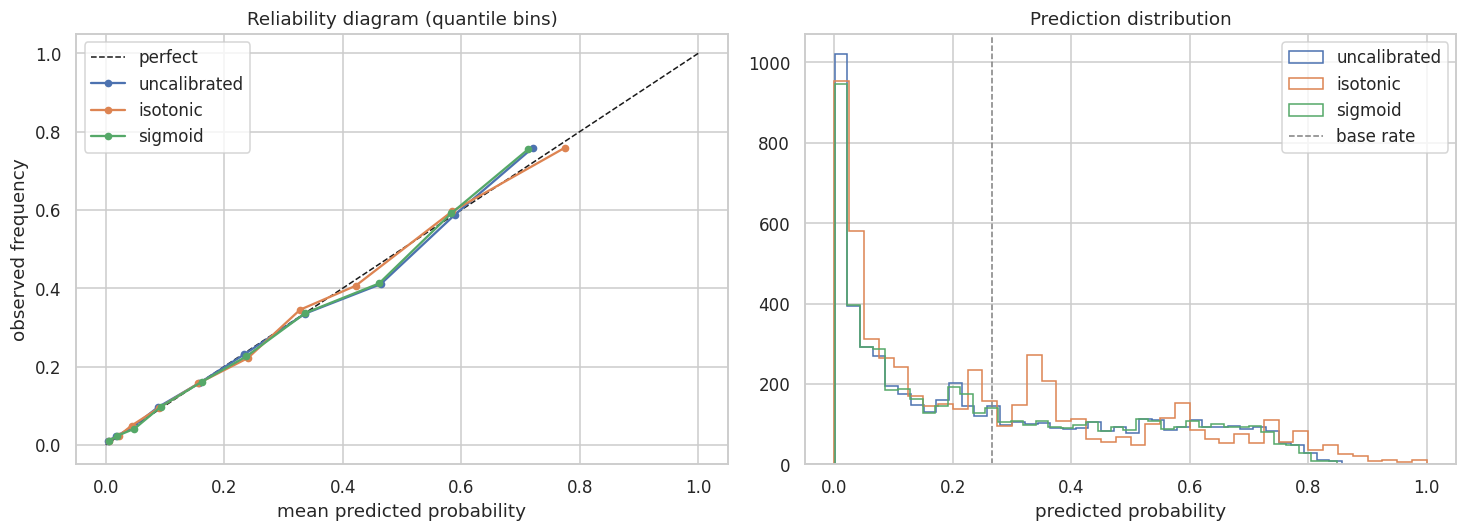

uncalibrated bias : +0.00025 (mean predicted 0.26560 vs observed 0.26535)
uncalibrated Brier: 0.13559 | log loss 0.41673

CHOSEN: uncalibrated
no calibration method improved both Brier and log loss. A method that wins on one proper scoring rule while losing on the other has not improved the probabilities, and adopting it on a cost difference smaller than fold noise would be selecting on validation noise. Skipped, which also removes a moving part between this notebook and production.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for name, proba in oof_proba.items():
    frac, mean_pred = calibration_curve(y, proba, n_bins=10, strategy="quantile")
    axes[0].plot(mean_pred, frac, marker="o", ms=4, label=name)
axes[0].set_xlabel("mean predicted probability")
axes[0].set_ylabel("observed frequency")
axes[0].set_title("Reliability diagram (quantile bins)")
axes[0].legend()

for name, proba in oof_proba.items():
    axes[1].hist(proba, bins=40, histtype="step", lw=1.5, label=name)
axes[1].axvline(y.mean(), color="grey", ls="--", lw=1, label="base rate")
axes[1].set_xlabel("predicted probability")
axes[1].set_title("Prediction distribution")
axes[1].legend()

plt.tight_layout(); plt.show()

# Judge calibration on what calibration is FOR: probability quality, measured by
# proper scoring rules. Ranking by expected cost here would again be selecting on
# validation noise, and cost is the wrong instrument besides — it responds to the
# threshold as much as to the probabilities.
base = calib.set_index("variant").loc["uncalibrated"]
comp = calib.set_index("variant").drop(index="uncalibrated")

improved = comp[(comp["brier"] < base["brier"]) & (comp["log_loss"] < base["log_loss"])]

print(f"uncalibrated bias : {base['bias']:+.5f} "
      f"(mean predicted {base['mean_pred']:.5f} vs observed {base['observed_rate']:.5f})")
print(f"uncalibrated Brier: {base['brier']:.5f} | log loss {base['log_loss']:.5f}\n")

if len(improved):
    CALIBRATION = improved.sort_values("brier").index[0]
    calibration_reason = (
        f"{CALIBRATION} improves BOTH Brier and log loss against uncalibrated."
    )
else:
    CALIBRATION = "uncalibrated"
    calibration_reason = (
        "no calibration method improved both Brier and log loss. A method that wins "
        "on one proper scoring rule while losing on the other has not improved the "
        "probabilities, and adopting it on a cost difference smaller than fold noise "
        "would be selecting on validation noise. Skipped, which also removes a moving "
        "part between this notebook and production."
    )

print(f"CHOSEN: {CALIBRATION}")
print(calibration_reason)

---

## 7. Learning Curves

A single score cannot say whether effort should go into more data or better features. Converged curves with a small gap mean more rows will not help. A large persistent gap means overfitting. Both low and flat means underfitting.

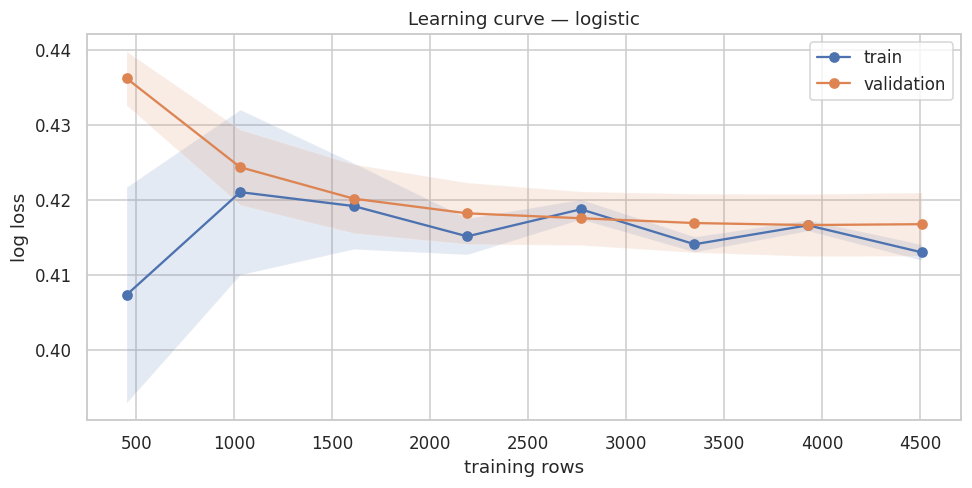

final train-validation gap : 0.0037
validation slope, last third: -0.00015

A flat validation curve means more rows will not help; invest in features.
A still-falling curve means more data would.


In [17]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(
    build_pipeline(CANDIDATES[BEST_MODEL]), X, y, cv=CV,
    train_sizes=np.linspace(0.1, 1.0, 8), scoring="neg_log_loss", n_jobs=-1,
)
budget.record("learning_curve", 1)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(sizes, -train_sc.mean(1), "o-", label="train")
ax.fill_between(sizes, -train_sc.mean(1) - train_sc.std(1),
                -train_sc.mean(1) + train_sc.std(1), alpha=0.15)
ax.plot(sizes, -val_sc.mean(1), "o-", label="validation")
ax.fill_between(sizes, -val_sc.mean(1) - val_sc.std(1),
                -val_sc.mean(1) + val_sc.std(1), alpha=0.15)
ax.set_xlabel("training rows"); ax.set_ylabel("log loss"); ax.legend()
ax.set_title(f"Learning curve — {BEST_MODEL}")
plt.tight_layout(); plt.show()

final_gap = (-val_sc.mean(1)[-1]) - (-train_sc.mean(1)[-1])
slope = (-val_sc.mean(1)[-1]) - (-val_sc.mean(1)[-3])
print(f"final train-validation gap : {final_gap:.4f}")
print(f"validation slope, last third: {slope:+.5f}")
print("\nA flat validation curve means more rows will not help; invest in features.")
print("A still-falling curve means more data would.")

---

## 8. Intervals, Not Points

A single figure conveys false precision. The bootstrap below resamples the out-of-fold predictions with stratification — without it, some resamples can contain no positive cases at all and the metric becomes degenerate, quietly biasing the interval.

In [18]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.utils import resample


def build_final_estimator():
    """The exact configuration that will be saved. Built once, used everywhere.

    Reported metrics must describe the artifact that ships. Measuring an untuned
    model and then saving a tuned one publishes an interval for a configuration
    nobody evaluated.
    """
    model = CANDIDATES[BEST_MODEL]
    if BEST_MODEL in best_params:
        tuned = {k.replace("model__", ""): v for k, v in best_params[BEST_MODEL].items()}
        model = model.__class__(**{**model.get_params(), **tuned})
    est = build_pipeline(model)
    if CALIBRATION != "uncalibrated":
        est = CalibratedClassifierCV(
            est, method="isotonic" if CALIBRATION == "isotonic" else "sigmoid", cv=3)
    return est


FINAL_EST = build_final_estimator()
print(f"final configuration: {BEST_MODEL} | {CALIBRATION} | {THRESHOLD_STRATEGY}")
print(f"tuned params applied: {bool(best_params.get(BEST_MODEL))}\n")

# Out-of-fold predictions from the FINAL configuration, on the same folds.
proba_best = cross_val_predict(FINAL_EST, X, y, cv=CV,
                               method="predict_proba", n_jobs=-1)[:, 1]
budget.record("final_config_oof", 1)

final_cv = cross_validate(FINAL_EST, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
budget.record("final_config_cv", 1)
FINAL_COST = -final_cv["test_neg_cost"].mean()
print(f"final config per-fold cost: {np.round(-final_cv['test_neg_cost'], 3)}")
print(f"mean USD {FINAL_COST:.3f} (sd {final_cv['test_neg_cost'].std():.3f})")
rng = np.random.RandomState(RANDOM_SEED)
idx = np.arange(len(y))

boot = {"roc_auc": [], "average_precision": [], "cost": []}
for _ in range(1000):
    b = resample(idx, stratify=y, random_state=rng.randint(1_000_000))
    yb, pb = y.iloc[b], proba_best[b]
    mc, ct = X.iloc[b]["MonthlyCharges"], X.iloc[b]["Contract"]
    action = (policy_from_proba(pb, mc, ct) if THRESHOLD_STRATEGY == "cost_derived"
              else (pb > (0.5 if THRESHOLD_STRATEGY == "cost_at_0.5"
                          else thr["t_empirical_inner"].mean())).astype(int))
    boot["roc_auc"].append(roc_auc_score(yb, pb))
    boot["average_precision"].append(average_precision_score(yb, pb))
    boot["cost"].append(cost_per_customer(yb, action, mc, ct))

ci = pd.DataFrame({
    k: {"mean": np.mean(v), "lo_2.5": np.percentile(v, 2.5), "hi_97.5": np.percentile(v, 97.5)}
    for k, v in boot.items()
}).T
display(ci.round(4))

lo, hi = np.percentile(boot["cost"], [2.5, 97.5])
cap_lo = (BEST_NAIVE - hi) / HEADROOM
cap_hi = (BEST_NAIVE - lo) / HEADROOM
cap_point = (BEST_NAIVE - np.mean(boot["cost"])) / HEADROOM

PASS_AT, ABORT_BELOW = 0.40, 0.15
print(f"\nHeadroom captured : {cap_point:.1%}  95% CI [{cap_lo:.1%}, {cap_hi:.1%}]")
print(f"Rule fixed in notebook 01: continue at >={PASS_AT:.0%}, abandon below {ABORT_BELOW:.0%}")

if cap_lo >= PASS_AT:
    VERDICT = "PASS"
    verdict_note = "the whole interval clears the continue threshold."
elif cap_hi < ABORT_BELOW:
    VERDICT = "ABANDON"
    verdict_note = "the whole interval sits below the abandon threshold."
elif cap_hi < PASS_AT:
    VERDICT = "DOES NOT CLEAR"
    verdict_note = (
        "the interval never reaches the continue threshold, so the model does not "
        "meet the bar this project set for itself before any modelling began. "
        f"The lower bound also falls below {ABORT_BELOW:.0%}, meaning the data cannot "
        "settle which side of the abandon line the true value lies on."
    )
else:
    VERDICT = "INCONCLUSIVE"
    verdict_note = "the interval spans the decision boundary; more data or a better feature set is needed to resolve it."

print(f"\nVERDICT: {VERDICT}")
print(verdict_note)
print("\nThis is a result, not a failure. A rule fixed in advance and then honoured")
print("is worth more than a rule adjusted afterwards to match the outcome.")

final configuration: logistic | uncalibrated | cost_derived
tuned params applied: True

final config per-fold cost: [ 95.606  97.877 100.629  97.286  95.171]
mean USD 97.314 (sd 1.940)


,mean,lo_2.5,hi_97.5
roc_auc,0.8456,0.8353,0.8563
average_precision,0.6555,0.6336,0.6773
cost,97.2765,95.0382,99.4680



Headroom captured : 23.6%  95% CI [10.5%, 36.9%]
Rule fixed in notebook 01: continue at >=40%, abandon below 15%

VERDICT: DOES NOT CLEAR
the interval never reaches the continue threshold, so the model does not meet the bar this project set for itself before any modelling began. The lower bound also falls below 15%, meaning the data cannot settle which side of the abandon line the true value lies on.

This is a result, not a failure. A rule fixed in advance and then honoured
is worth more than a rule adjusted afterwards to match the outcome.


---

## 9. Decision and Handoff

In [19]:
budget_df = budget.report()

                               label  configs
                    untuned:logistic        1
               untuned:random_forest        1
                 untuned:extra_trees        1
      untuned:hist_gradient_boosting        1
              nested_search:logistic       75
nested_search:hist_gradient_boosting       75
                flat_search:logistic       25
  flat_search:hist_gradient_boosting       25
                 threshold_selection        3
            calibration:uncalibrated        1
                calibration:isotonic        1
                 calibration:sigmoid        1
                      learning_curve        1
                    final_config_oof        1
                     final_config_cv        1

Total validation queries: 213
High. Expect the gap between validation and test to widen.


In [20]:
# Refit the SAME estimator that Part 8 measured, on all training data. Building a
# second object here is how a published interval ends up describing a different
# model from the one that ships.
final_pipeline = build_final_estimator()
final_pipeline.fit(X, y)
joblib.dump(final_pipeline, OUT_DIR / "final_pipeline.joblib")

# Verify the artifact reloads and predicts identically. A pipeline that fails to
# round-trip is a production incident discovered at the worst possible time.
reloaded = joblib.load(OUT_DIR / "final_pipeline.joblib")
assert np.allclose(reloaded.predict_proba(X.head(50))[:, 1],
                   final_pipeline.predict_proba(X.head(50))[:, 1])
print(f"final_pipeline.joblib written and verified ({BEST_MODEL}, {CALIBRATION})")

final_pipeline.joblib written and verified (logistic, uncalibrated)


In [21]:
selection = {
    "notebook": "04_model_selection",
    "random_seed": RANDOM_SEED,
    "cv_scheme": f"StratifiedKFold(n_splits=5, shuffle=True, random_state={RANDOM_SEED})",
    "chosen_model": BEST_MODEL,
    "chosen_calibration": CALIBRATION,
    "chosen_threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_reason": threshold_reason,
    "calibration_reason": calibration_reason,
    "final_config_cv_cost": round(float(FINAL_COST), 4),
    "verdict": VERDICT,
    "verdict_note": verdict_note,
    "headroom_captured_point": round(float(cap_point), 4),
    "best_params": {k: str(v) for k, v in best_params.get(BEST_MODEL, {}).items()},
    "untuned_comparison": untuned.round(5).to_dict("records"),
    "nested_vs_flat": opt.round(6).to_dict("index"),
    "threshold_analysis": {
        "mean_costs": {k: round(float(v), 4) for k, v in means.items()},
        "validation_selection_optimism": round(float(optimism_thr), 4),
        "mean_empirical_threshold": round(float(thr["t_empirical_inner"].mean()), 4),
    },
    "calibration": calib.round(5).to_dict("records"),
    "bootstrap_ci": ci.round(5).to_dict("index"),
    "headroom_captured_ci": [round(float(cap_lo), 4), round(float(cap_hi), 4)],
    "learning_curve": {
        "final_gap": round(float(final_gap), 5),
        "validation_slope_last_third": round(float(slope), 6),
    },
    "significance": {
        "friedman_p": round(float(p_friedman), 5),
        "pairwise_holm": pw_df.round(5).to_dict("records") if pw_df is not None else None,
    },
    "validation_queries": int(budget.total),
    "query_log": budget.log,
    "benchmarks": {"oracle": ORACLE, "best_naive": BEST_NAIVE,
                   "headroom": HEADROOM, "baseline_cost": BASELINE_COST},
}

(OUT_DIR / "model_selection.json").write_text(json.dumps(selection, indent=2))
print(json.dumps({k: v for k, v in selection.items()
                  if k not in ("untuned_comparison", "calibration", "query_log")},
                 indent=2))

{
  "notebook": "04_model_selection",
  "random_seed": 29,
  "cv_scheme": "StratifiedKFold(n_splits=5, shuffle=True, random_state=29)",
  "chosen_model": "logistic",
  "chosen_calibration": "uncalibrated",
  "chosen_threshold_strategy": "cost_derived",
  "threshold_reason": "the three honest strategies differ by USD 0.210, well inside the fold-to-fold noise of USD 2.207. The derived threshold is chosen on principle rather than by score: it uses no labels, so it cannot overfit, and it is the only one that adapts per customer to contract horizon and bill size.",
  "calibration_reason": "no calibration method improved both Brier and log loss. A method that wins on one proper scoring rule while losing on the other has not improved the probabilities, and adopting it on a cost difference smaller than fold noise would be selecting on validation noise. Skipped, which also removes a moving part between this notebook and production.",
  "final_config_cv_cost": 97.3137,
  "verdict": "DOES NOT CLE

---

## Summary

| Item | Result |
| :--- | :--- |
| Models compared | Logistic, random forest, extra trees, histogram gradient boosting |
| Omnibus test | Friedman across all four before any pairwise comparison |
| Tuning | Randomised search, nested — inner loop tunes, outer loop estimates |
| Optimism quantified | Nested versus flat score, reported rather than hidden |
| Threshold | Selected inside the loop, compared against the derived formula and 0.5 |
| Leakage priced | What validation-fold threshold selection would have overstated by |
| Calibration | Isotonic and sigmoid measured against uncalibrated on cost |
| Uncertainty | Stratified bootstrap, 1,000 resamples, reported as intervals |
| Query budget | Counted and recorded in the artifact |

**What remains untouched:** `test.parquet`. It is opened exactly once, in notebook 05.

**Expect regression to the mean.** The gap between the best validation score and the final test score widens with the number of configurations tried. The query count in `model_selection.json` is the honest basis for deciding how much to discount — a result selected from a wide search is optimistically biased almost by construction, and that is true even when every individual step followed the rules.